In [1]:
# Librairies essentielles
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Pour que les graphiques s'affichent directement dans le notebook
%matplotlib inline

In [2]:
# Choix des actions / Paire pour le trading
tickers = ["AAPL", "MSFT"]

# Télécharge les données pour 2023 et ne garde que la clôture
data = yf.download(tickers, start="2023-01-01", end="2024-01-01")['Close']
data.dropna(inplace=True)

# Affiche les premières lignes
data.head()

[*********************100%***********************]  2 of 2 completed


Ticker,AAPL,MSFT
Date,,
2023-01-03,123.211212,233.985657
2023-01-04,124.482040,223.750366
2023-01-05,123.161957,217.118927
2023-01-06,127.693581,219.677734
2023-01-09,128.215714,221.816574


In [3]:
# Calcul du spread et du z-score
data['spread'] = data[tickers[0]] - data[tickers[1]]

spread_mean = data['spread'].mean()
spread_std = data['spread'].std()

data['zscore'] = (data['spread'] - spread_mean) / spread_std

In [4]:
# Définition d'une stratégie simple
entry_threshold = 1.0
exit_threshold = 0.0

data['position'] = 0
# Short spread 
data.loc[data['zscore'] > entry_threshold, 'position'] = -1

# Long spread
data.loc[data['zscore'] < -entry_threshold, 'position'] = 1

data['postion'] = data['position'].ffill()
data.loc[data['zscore'].abs() < exit_threshold, 'position'] = 0

In [5]:
# Backtesting simple
data['spread_returns'] = data['spread'].diff()
data['strategy_returns'] = data['position'].shift(1) * data['spread_returns']
data['cumulative_strategy_returns'] = data['strategy_returns'].cumsum()

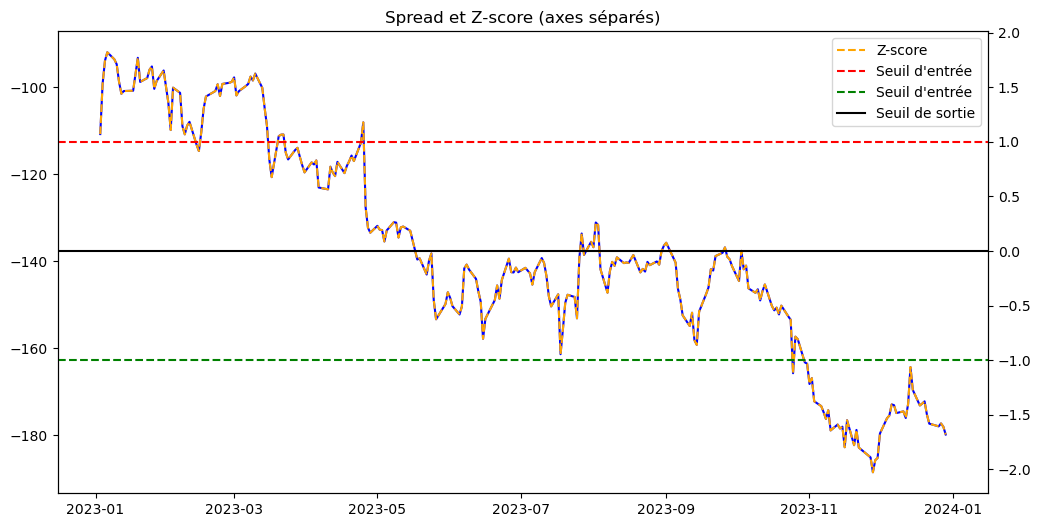

In [6]:
plt.figure(figsize=(12,6))

# Axe principal : le spread
plt.plot(data['spread'], color='blue', label='Spread')

# Crée un second axe Y pour le z-score
ax2 = plt.gca().twinx()
ax2.plot(data['zscore'], color='orange', label='Z-score', linestyle='--')
ax2.axhline(entry_threshold, color='red', linestyle='--', label='Seuil d\'entrée')
ax2.axhline(-entry_threshold, color='green', linestyle='--', label='Seuil d\'entrée')
ax2.axhline(0, color='black', linestyle='-', label='Seuil de sortie')

plt.title("Spread et Z-score (axes séparés)")
plt.xlabel("Date")
plt.gca().legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

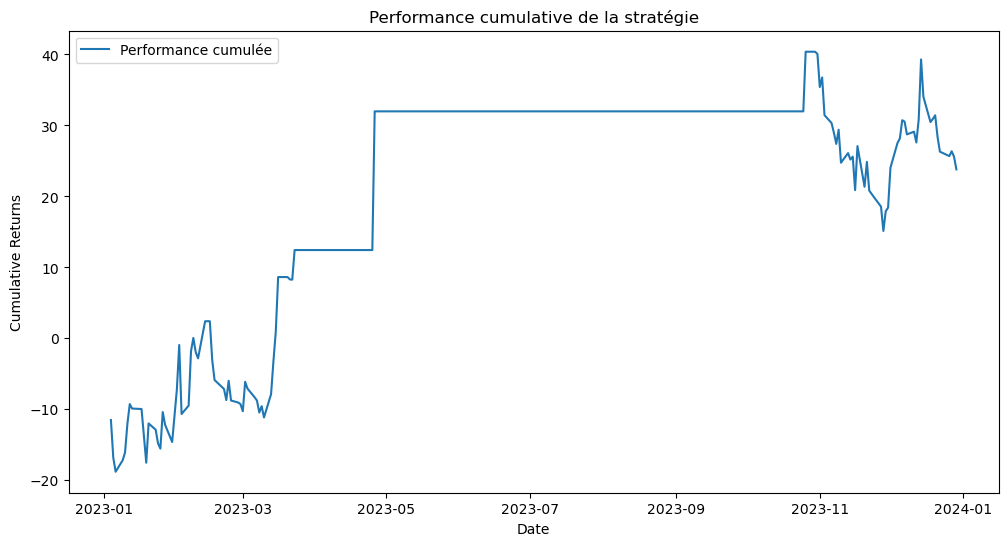

In [7]:
plt.figure(figsize=(12,6))
plt.plot(data['cumulative_strategy_returns'], label='Performance cumulée')
plt.title("Performance cumulative de la stratégie")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.legend()
plt.show()